# 📊 Análise de Preços de Carros — Dataset FIPE (Brasil)

**Fundamentos de Pesquisa em Ciência da Computação II — Visualização de Dados**

Este notebook explora o dataset da tabela FIPE (preços médios de carros no Brasil, Jan/2021–Jan/2023) através de 8 visualizações provocativas, cada uma acompanhada de uma pergunta orientadora e pontos de debate.

**Fonte dos dados:** [FIPE](https://veiculos.fipe.org.br/)

**Princípios de visualização aplicados** (baseado no material de Fabio Morais — PPGCC/UFCG):
- Expressividade: mostrar tudo que é necessário, nem mais nem menos
- Efetividade: usar o melhor método visual para cada tipo de pergunta
- Evitar gráficos de pizza — preferir barras ordenadas
- Paleta de cores consistente ao longo do notebook


## 1. Setup e carregamento dos dados

In [ ]:
# Instalação de dependências (Colab já tem a maioria, garantindo versões)
!pip install -q pandas matplotlib seaborn numpy


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual consistente (paleta e estilo usados em todo o notebook)
sns.set_theme(style="whitegrid")
PALETTE = "viridis"
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12


### 1.1 Carregando o dataset

**Opção A — Upload manual no Colab (recomendado):** rode a célula abaixo, clique em "Escolher arquivos" e selecione o `archive.zip` (contém `fipe_cars.csv` e `fipe_2022.csv`) baixado do Kaggle.

**Opção B — Google Drive:** se preferir, monte o Drive e ajuste o caminho na célula seguinte.


In [ ]:
from google.colab import files
import zipfile
import io

uploaded = files.upload()  # selecione o archive.zip

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_name])) as z:
    z.extractall("dataset")
    print(z.namelist())


Saving archive.zip to archive.zip
['fipe_2022.csv', 'fipe_cars.csv']


In [ ]:
# Usamos o fipe_2022.csv, que já traz a coluna age_years calculada
df = pd.read_csv("dataset/fipe_2022.csv")

print(df.shape)
df.head()


(290275, 12)


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,age_years
0,2022,January,038001-6,vwmrywl5qs,Acura,NSX 3.0,Gasoline,manual,3.0,1995,43779.0,28
1,2022,January,038001-6,t9mt723qhz,Acura,NSX 3.0,Gasoline,manual,3.0,1994,42244.0,29
2,2022,January,038001-6,tr5wv4z21g,Acura,NSX 3.0,Gasoline,manual,3.0,1993,40841.0,30
3,2022,January,038001-6,s2xxsjz3mt,Acura,NSX 3.0,Gasoline,manual,3.0,1992,39028.0,31
4,2022,January,038001-6,rtm9gj7zk8,Acura,NSX 3.0,Gasoline,manual,3.0,1991,35678.0,32


In [ ]:
df.info()
print()
print("Valores nulos por coluna:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290275 entries, 0 to 290274
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   year_of_reference   290275 non-null  int64  
 1   month_of_reference  290275 non-null  object 
 2   fipe_code           290275 non-null  object 
 3   authentication      290275 non-null  object 
 4   brand               290275 non-null  object 
 5   model               290275 non-null  object 
 6   fuel                290275 non-null  object 
 7   gear                290275 non-null  object 
 8   engine_size         290275 non-null  float64
 9   year_model          290275 non-null  int64  
 10  avg_price_brl       290275 non-null  float64
 11  age_years           290275 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 26.6+ MB

Valores nulos por coluna:
year_of_reference     0
month_of_reference    0
fipe_code             0
authentication        0
bra

## 2. Preparação dos dados

Como o dataset traz **múltiplas observações mensais para o mesmo carro** (mesmo `fipe_code` aparece em vários meses de referência), usamos o **preço mais recente disponível** (último `month_of_reference` de 2022) por combinação de carro, para evitar duplicidade artificial nos gráficos de distribuição.


In [ ]:
# Mapeamento de meses para ordenação
meses_ordem = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["month_num"] = pd.Categorical(df["month_of_reference"], categories=meses_ordem, ordered=True)

# Pega a observação mais recente por fipe_code + year_model (evita duplicar o mesmo carro em vários meses)
df_sorted = df.sort_values(["fipe_code", "year_model", "year_of_reference", "month_num"])
df_latest = df_sorted.groupby(["fipe_code", "year_model"], as_index=False).tail(1).copy()

print(f"Linhas originais: {len(df):,}")
print(f"Linhas após deduplicação (carro mais recente): {len(df_latest):,}")

# Remove outliers extremos de preço (top/bottom 0.5%) só para os gráficos — mantém df_latest intacto para referência
p_low, p_high = df_latest["avg_price_brl"].quantile([0.005, 0.995])
df_viz = df_latest[(df_latest["avg_price_brl"] >= p_low) & (df_latest["avg_price_brl"] <= p_high)].copy()
print(f"Linhas após remover outliers extremos (0.5%-99.5%): {len(df_viz):,}")


Linhas originais: 290,275
Linhas após deduplicação (carro mais recente): 24,033
Linhas após remover outliers extremos (0.5%-99.5%): 23,791


---
## 3. Preço por tipo de combustível (Boxplot)

**Pergunta:** Carros a Diesel realmente valem mais que Gasolina/Álcool no Brasil?

**Possível debate:**
- O preço do Diesel compensa o menor consumo e maior durabilidade do motor?
- Carros a Álcool (flex) são mais acessíveis por serem mais populares/antigos?
- A diferença é sobre o combustível em si ou sobre o perfil de carro que usa cada um (picapes/SUVs a Diesel vs. populares a Álcool)?


/tmp/ipykernel_2468/2761133273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


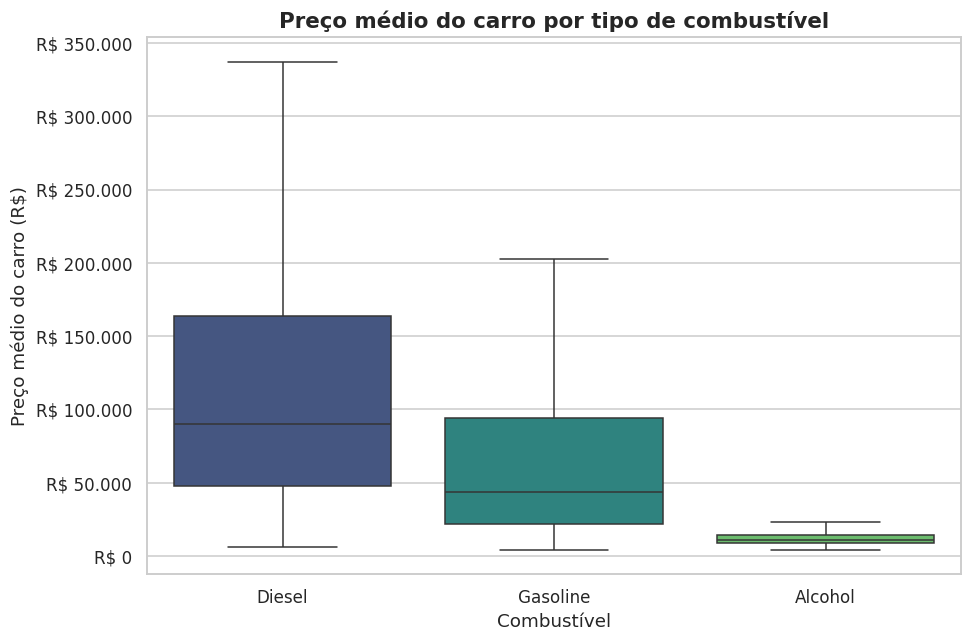

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

order = df_viz.groupby("fuel")["avg_price_brl"].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_viz, x="fuel", y="avg_price_brl", order=order,
    palette=PALETTE, showfliers=False, ax=ax
)

ax.set_title("Preço médio do carro por tipo de combustível")
ax.set_xlabel("Combustível")
ax.set_ylabel("Preço médio do carro (R$)")
ax.yaxis.set_major_formatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))

plt.tight_layout()
plt.show()


---
## 4. Preço por marca (Violino — Top 15 marcas por volume)

**Pergunta:** Você paga pela marca ou pelas características técnicas do carro?

**Possível debate:**
- BMW e Mercedes são realmente superiores tecnicamente ou apenas mais valorizadas pela marca?
- Marcas populares (Fiat, Chevrolet, VW) têm menor variação de preço — isso é bom ou ruim para o consumidor?
- O "efeito marca" se sustenta mesmo entre carros de especificações parecidas?


/tmp/ipykernel_2468/725828726.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


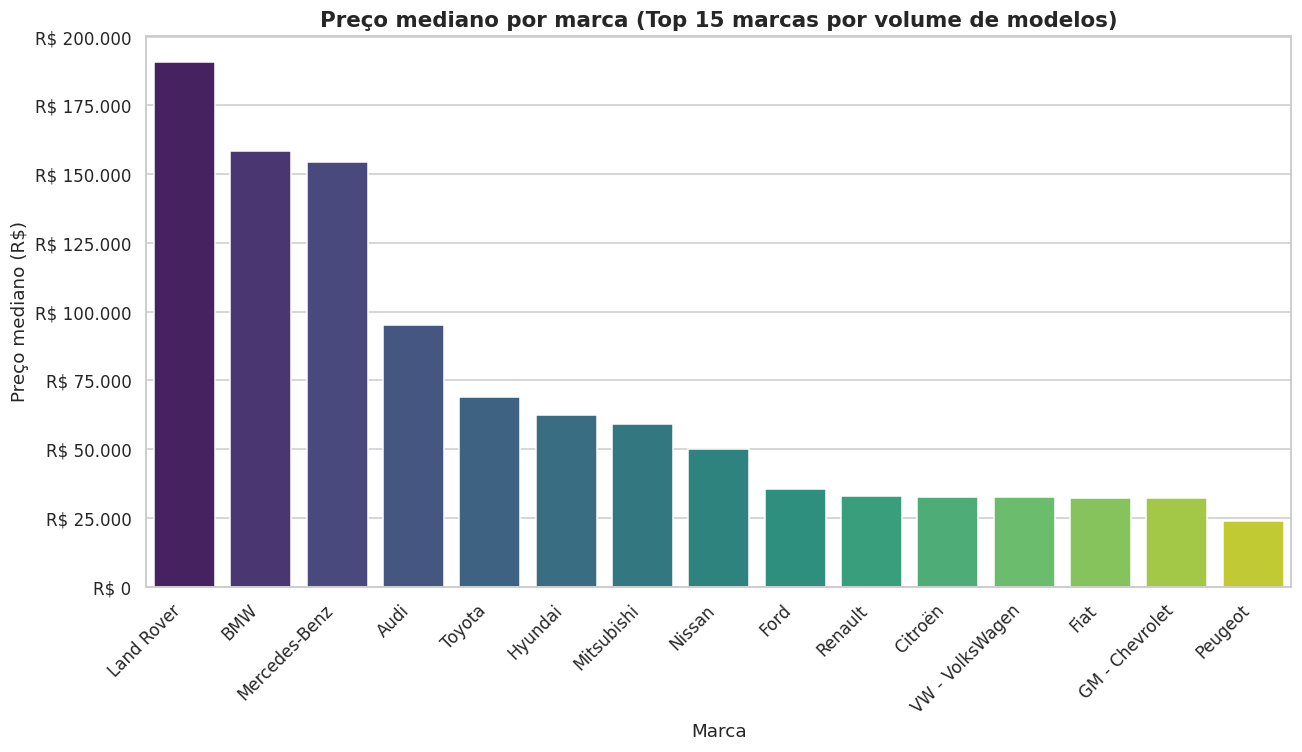

In [ ]:
top_marcas = df_viz["brand"].value_counts().head(15).index
df_top_marcas = df_viz[df_viz["brand"].isin(top_marcas)]

# Mediana do preço por marca
preco_marca = (
    df_top_marcas.groupby("brand")["avg_price_brl"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    x=preco_marca.index,
    y=preco_marca.values,
    palette=PALETTE,
    ax=ax
)

ax.set_title("Preço mediano por marca (Top 15 marcas por volume de modelos)")
ax.set_xlabel("Marca")
ax.set_ylabel("Preço mediano (R$)")
ax.yaxis.set_major_formatter(
    lambda x, pos: f"R$ {x:,.0f}".replace(",", ".")
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 5. Idade do carro vs Preço (Scatter Plot)

**Pergunta:** Quanto a idade do carro realmente afeta o valor? Existe um "ponto de corte" psicológico?

**Possível debate:**
- Existe um limite de idade (ex: 10-15 anos) onde a desvalorização estabiliza?
- Carros a Diesel desvalorizam menos com a idade do que Gasolina/Álcool?
- A relação é linear ou exponencial (desvalorização mais forte nos primeiros anos)?

*Nota: usamos uma amostra aleatória para manter o gráfico legível, já que o dataset completo tem centenas de milhares de pontos.*


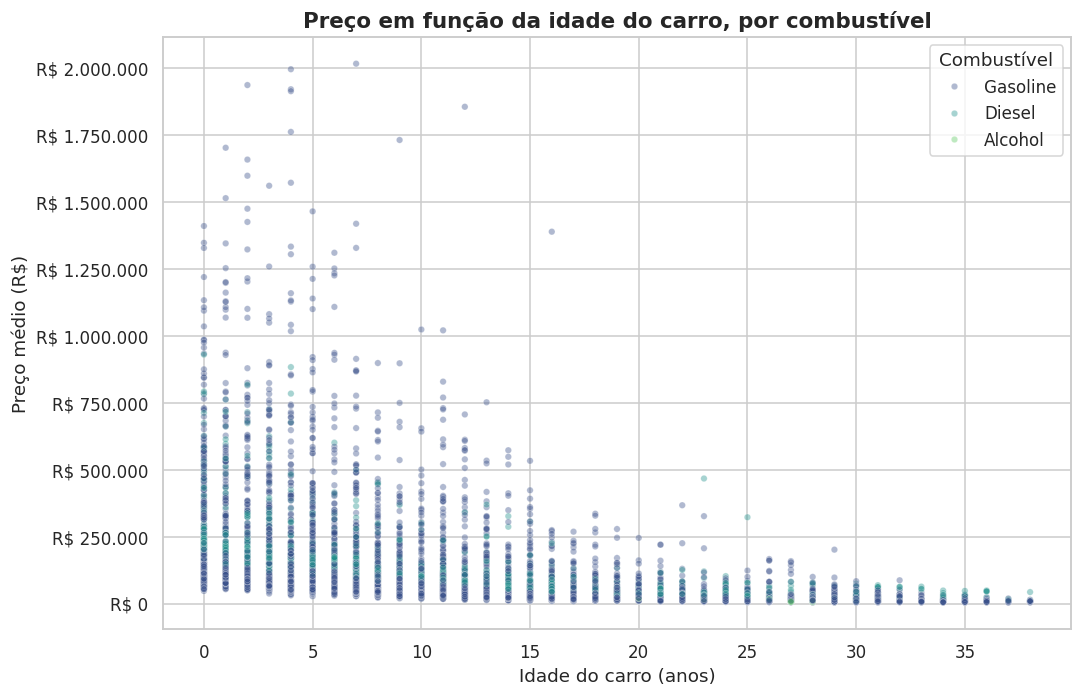

In [ ]:
amostra = df_viz.sample(n=min(8000, len(df_viz)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(
    data=amostra, x="age_years", y="avg_price_brl", hue="fuel",
    palette=PALETTE, alpha=0.4, s=18, ax=ax
)

ax.set_title("Preço em função da idade do carro, por combustível")
ax.set_xlabel("Idade do carro (anos)")
ax.set_ylabel("Preço médio (R$)")
ax.yaxis.set_major_formatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))
ax.legend(title="Combustível")

plt.tight_layout()
plt.show()


---
## 6. Ano-modelo vs Preço médio (Linha com tendência)

**Pergunta:** Carro novo sempre vale mais? A desvalorização é linear ao longo dos anos?

**Possível debate:**
- Existem "vales" ou "picos" em anos específicos (crise econômica, mudança de geração do modelo)?
- A curva de desvalorização é mais acentuada nos primeiros anos de uso?


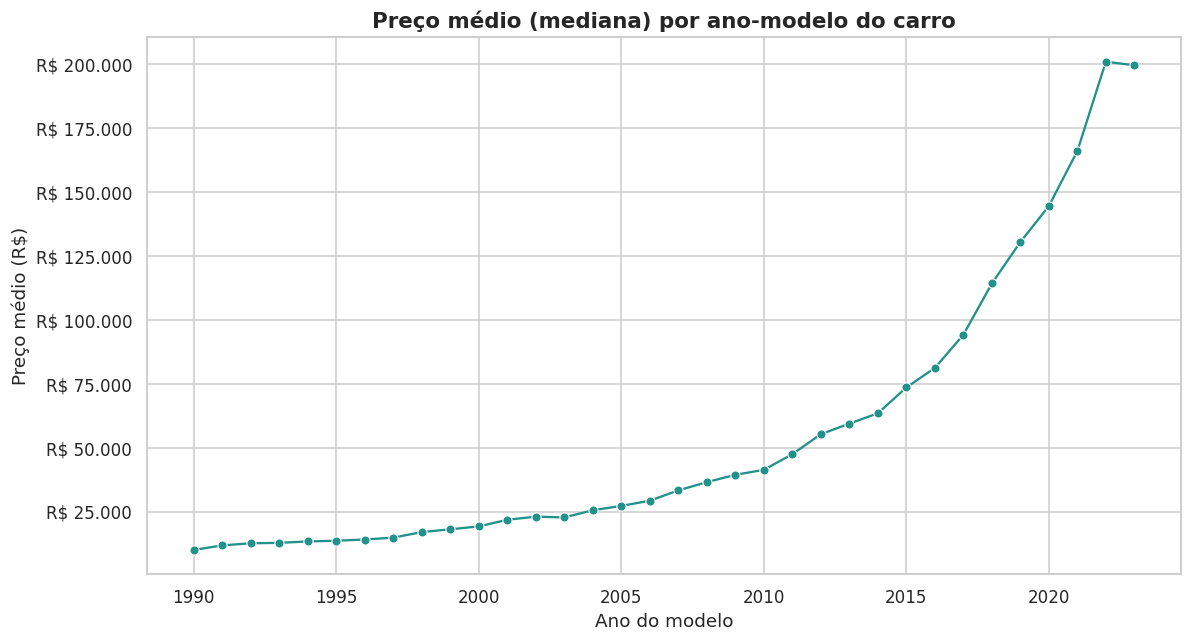

In [ ]:
preco_por_ano = (
    df_viz.groupby("year_model")["avg_price_brl"]
    .median()
    .reset_index()
    .query("year_model >= 1990")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=preco_por_ano, x="year_model", y="avg_price_brl",
    marker="o", color=sns.color_palette(PALETTE, 1)[0], ax=ax
)

ax.set_title("Preço médio (mediana) por ano-modelo do carro")
ax.set_xlabel("Ano do modelo")
ax.set_ylabel("Preço médio (R$)")
ax.yaxis.set_major_formatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))

plt.tight_layout()
plt.show()


---
## 7. Câmbio (Manual vs Automático) vs Preço (Boxplot)

**Pergunta:** O câmbio automático realmente vale o preço extra?

**Possível debate:**
- A diferença de preço reflete o câmbio em si ou o fato de carros automáticos serem, em média, mais recentes/completos?
- O câmbio manual "está morrendo" no mercado brasileiro?


/tmp/ipykernel_2468/335669754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


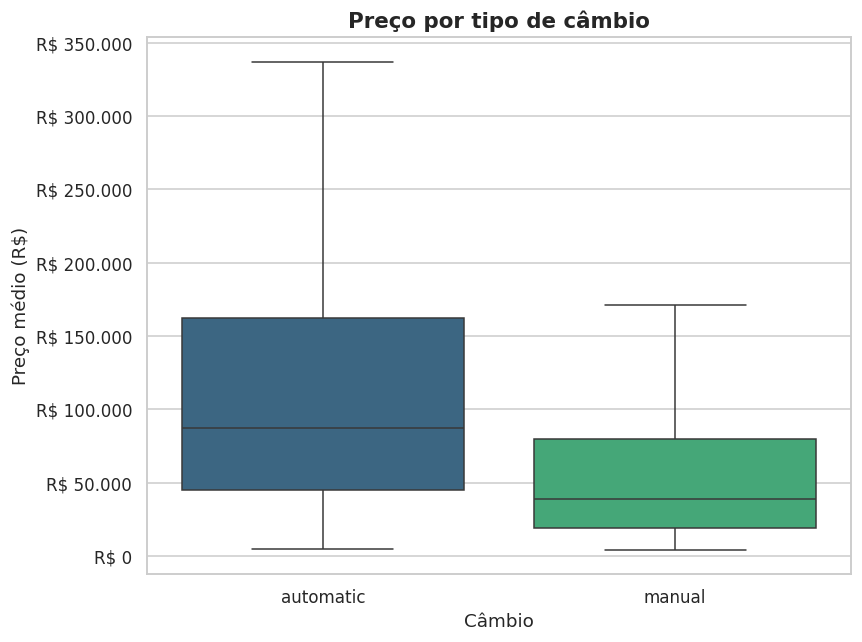

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

order_gear = df_viz.groupby("gear")["avg_price_brl"].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_viz, x="gear", y="avg_price_brl", order=order_gear,
    palette=PALETTE, showfliers=False, ax=ax
)

ax.set_title("Preço por tipo de câmbio")
ax.set_xlabel("Câmbio")
ax.set_ylabel("Preço médio (R$)")
ax.yaxis.set_major_formatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))

plt.tight_layout()
plt.show()


---
## 8. Tamanho do motor vs Preço (Scatter Plot)

**Pergunta:** Motor maior realmente significa carro mais caro?

**Possível debate:**
- A relação entre cilindrada e preço é mais forte que a relação entre idade e preço?
- Existem "saltos" de preço em faixas específicas de motorização (ex: acima de 2.0)?


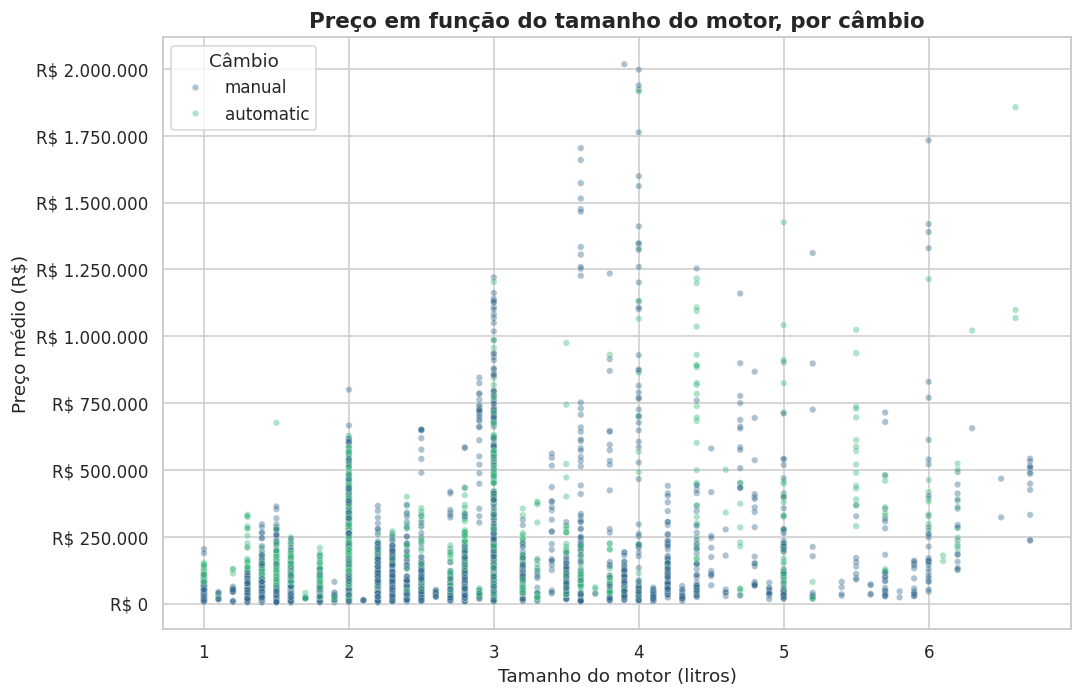

In [ ]:
amostra2 = df_viz.sample(n=min(8000, len(df_viz)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(
    data=amostra2, x="engine_size", y="avg_price_brl", hue="gear",
    palette=PALETTE, alpha=0.4, s=18, ax=ax
)

ax.set_title("Preço em função do tamanho do motor, por câmbio")
ax.set_xlabel("Tamanho do motor (litros)")
ax.set_ylabel("Preço médio (R$)")
ax.yaxis.set_major_formatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))
ax.legend(title="Câmbio")

plt.tight_layout()
plt.show()


---
## 9. Heatmap de correlação

**Pergunta:** O que realmente influencia o preço de um carro?

Variáveis numéricas consideradas: `avg_price_brl`, `year_model`, `engine_size`, `age_years`.

**Possível debate:**
- A idade pesa mais que o tamanho do motor na formação do preço?
- Existe correlação forte o suficiente para sustentar um modelo preditivo simples?


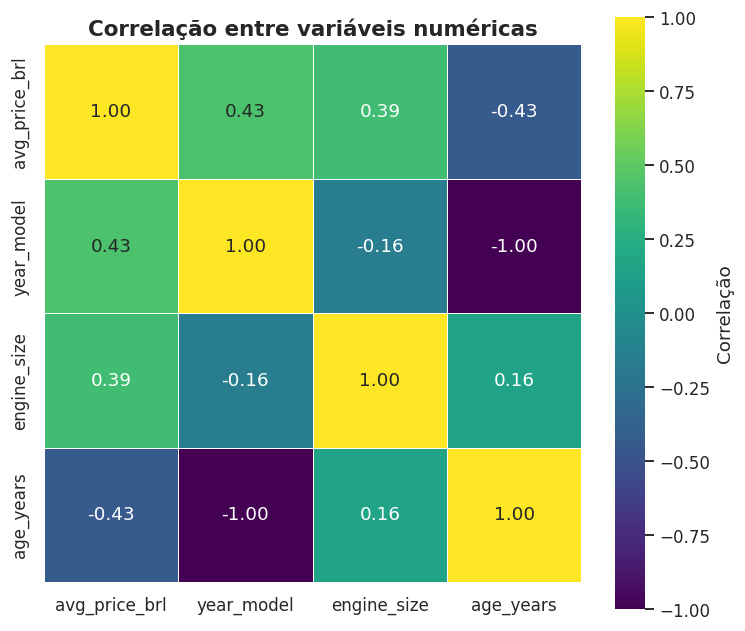

In [ ]:
cols_numericas = ["avg_price_brl", "year_model", "engine_size", "age_years"]
corr = df_viz[cols_numericas].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=PALETTE, center=0,
    square=True, linewidths=0.5, cbar_kws={"label": "Correlação"}, ax=ax
)

ax.set_title("Correlação entre variáveis numéricas")

plt.tight_layout()
plt.show()


---
## 10. Ranking das marcas mais valorizadas (Barras ordenadas)

**Pergunta:** Qual marca entrega o maior preço médio no mercado brasileiro?

Seguindo o princípio de visualização **"sempre evite gráficos de pizza, use barplots"**, este ranking usa barras horizontais ordenadas, que facilitam comparar e ordenar os valores — algo que um gráfico de pizza dificultaria com 15+ categorias.

**Possível debate:**
- Existe sobrepreço de marcas de luxo mesmo dentro do próprio segmento de luxo?
- Marcas populares bem avaliadas tecnicamente estão "subvalorizadas" no mercado?


/tmp/ipykernel_2468/2103591690.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


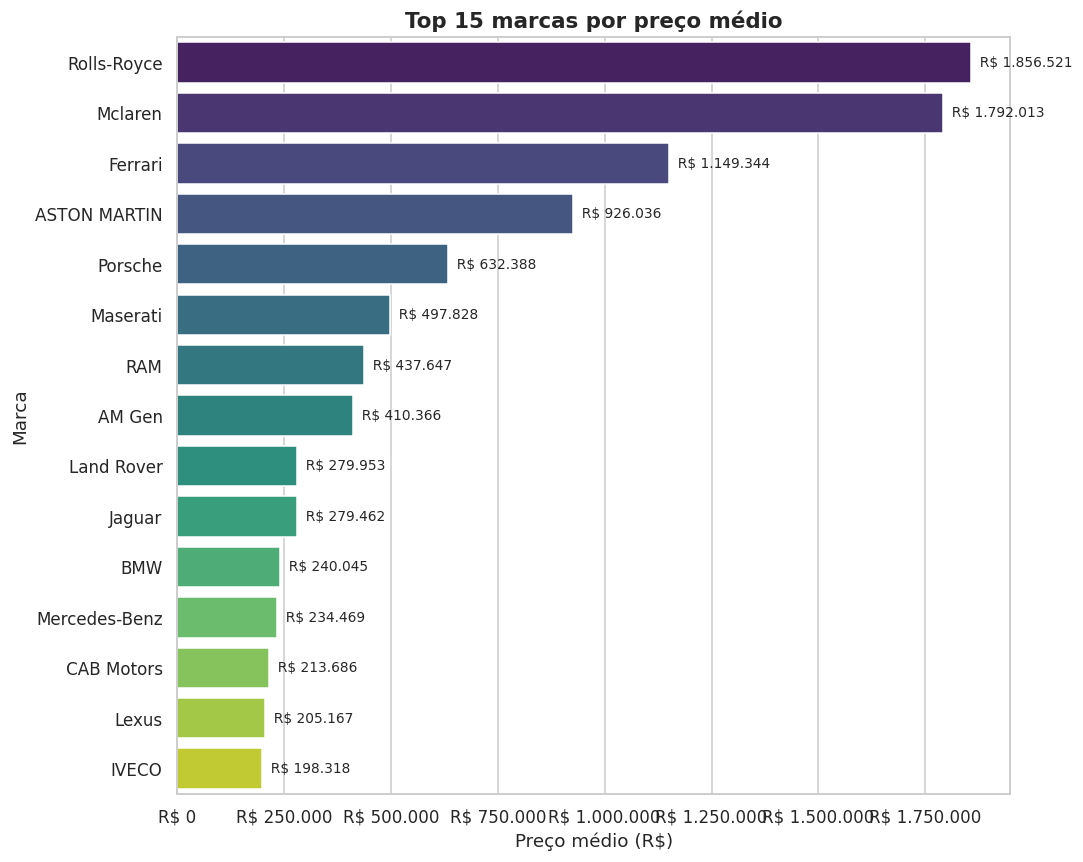

In [ ]:
top_n = 15
ranking = (
    df_viz.groupby("brand")["avg_price_brl"]
    .mean()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=ranking, y="brand", x="avg_price_brl",
    palette=PALETTE, order=ranking["brand"], ax=ax
)

ax.set_title(f"Top {top_n} marcas por preço médio")
ax.set_xlabel("Preço médio (R$)")
ax.set_ylabel("Marca")
ax.xaxis.set_major_formatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))

for i, v in enumerate(ranking["avg_price_brl"]):
    ax.text(v, i, f"  R$ {v:,.0f}".replace(",", "."), va="center", fontsize=9)

plt.tight_layout()
plt.show()


---
## 11. Resumo e próximos passos

Este notebook cobriu 8 visualizações exploratórias sobre o dataset FIPE de preços de carros no Brasil:

1. Preço por combustível
2. Preço por marca (top 15)
3. Idade vs Preço
4. Ano-modelo vs Preço (tendência)
5. Câmbio vs Preço
6. Tamanho do motor vs Preço
7. Heatmap de correlação
8. Ranking de marcas por preço médio

**Possíveis extensões:**
- Aplicar testes estatísticos (ex: Kruskal-Wallis) para validar diferenças entre grupos (combustível, câmbio, marca)
- Construir um modelo de regressão para prever `avg_price_brl` a partir de `age_years`, `engine_size` e `brand`
- Cruzar os preços com o salário mínimo brasileiro ao longo do tempo, como sugerido no dataset original, para uma análise "period-wise"


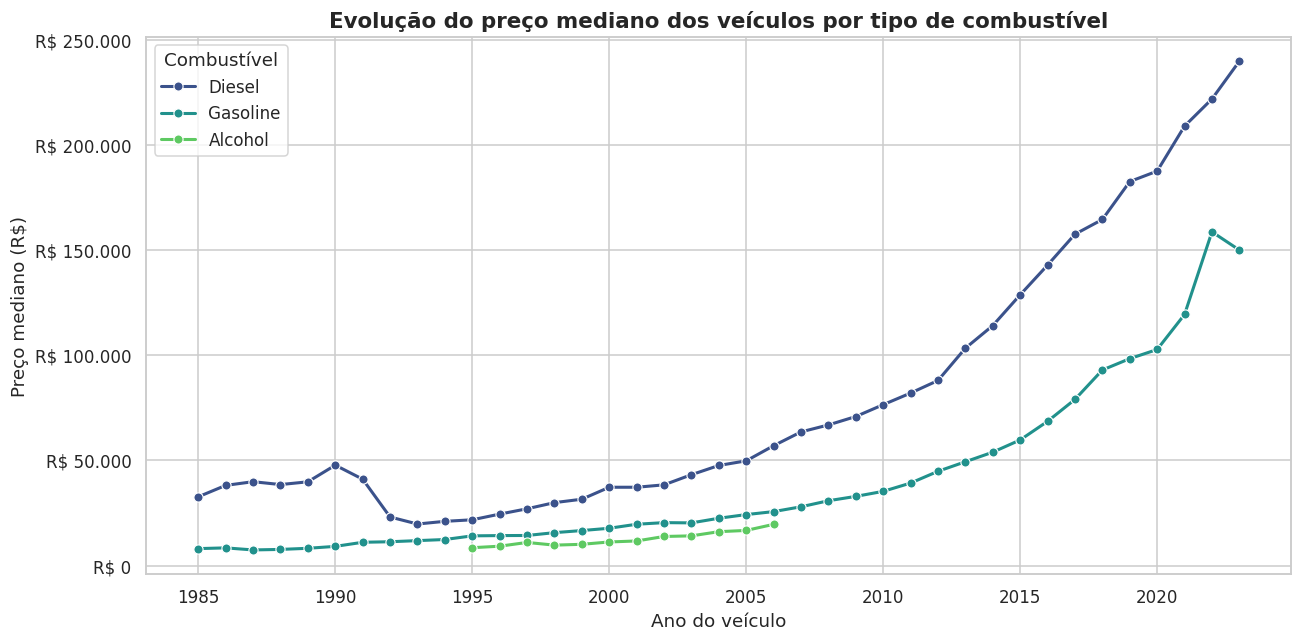

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preço mediano por ano e tipo de combustível
evolucao = (
    df_viz.groupby(["year_model", "fuel"])["avg_price_brl"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=evolucao,
    x="year_model",
    y="avg_price_brl",
    hue="fuel",
    marker="o",
    linewidth=2,
    palette=PALETTE,
    ax=ax
)

ax.set_title("Evolução do preço mediano dos veículos por tipo de combustível")
ax.set_xlabel("Ano do veículo")
ax.set_ylabel("Preço mediano (R$)")
ax.yaxis.set_major_formatter(
    lambda x, pos: f"R$ {x:,.0f}".replace(",", ".")
)

ax.legend(title="Combustível")
plt.tight_layout()
plt.show()



---





---



# 1. Mito dos 100 mil km (Scatter Plot)

(10000, 10)


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Price']
['brand', 'model', 'year', 'engine_size', 'fuel_type', 'transmission', 'mileage', 'doors', 'owner_count', 'price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         10000 non-null  object 
 1   model         10000 non-null  object 
 2   year          10000 non-null  int64  
 3   engine_size   10000 non-null  float64
 4   fuel_type     10000 non-null  object 
 5   transmission  10000 non-null  object 
 6   mileage       10000 non-null  int64  
 7   doors         10000 non-null  int64  
 8   owner_count   10000 non-null  int64  
 9   price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB
['brand', 'model', 'year', 'engine_size', 'fuel_type', 'transmission', 'mileage', 

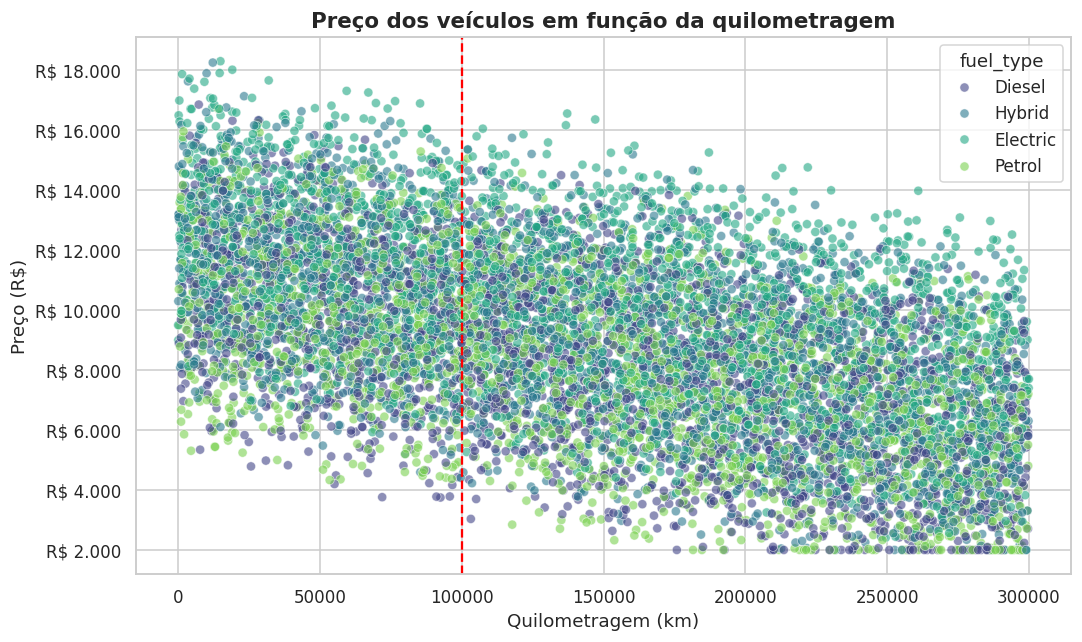

In [ ]:

# Carregar dataset
df2 = pd.read_csv("car_price_dataset.csv")

# Visualização inicial
print(df2.shape)
display(df2.head())

# Se estiver usando o arquivo que você acabou de enviar no Colab/Jupyter, recomendo verificar os nomes reais das colunas:

print(df2.columns.tolist())

# E já fazer uma padronização para facilitar os gráficos:

# Padronizar nomes
df2.columns = (
    df2.columns
    .str.lower()
    .str.strip()
)

print(df2.columns.tolist())

# Para eu gerar os gráficos sem erros, execute:

df2.info()

# ou

print(df2.columns.tolist())
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="mileage",
    y="price",
    hue="fuel_type",
    alpha=0.6,
    palette=PALETTE,
    ax=ax
)

ax.axvline(100000, color="red", linestyle="--", label="100 mil km")

ax.set_title("Preço dos veículos em função da quilometragem")
ax.set_xlabel("Quilometragem (km)")
ax.set_ylabel("Preço (R$)")
ax.yaxis.set_major_formatter(
    lambda x, pos: f"R$ {x:,.0f}".replace(",", ".")
)

plt.tight_layout()
plt.show()

# 2. Evolução do preço por tipo de câmbio

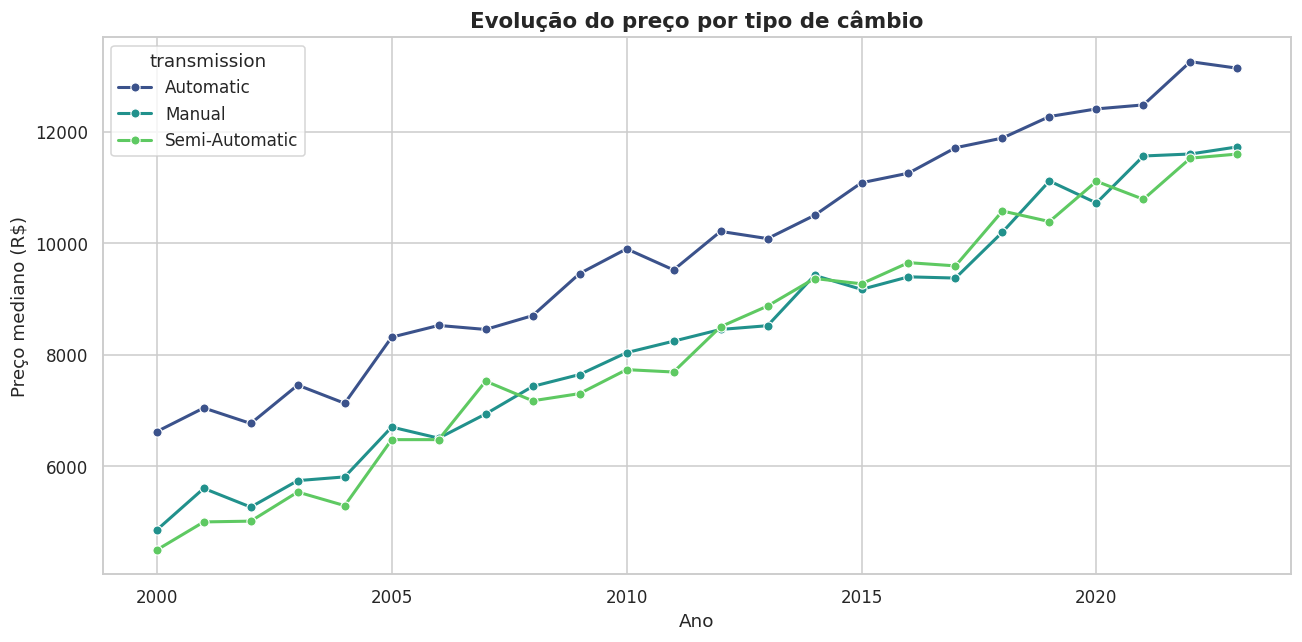

In [ ]:
preco_ano_cambio = (
    df2.groupby(["year", "transmission"])["price"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=preco_ano_cambio,
    x="year",
    y="price",
    hue="transmission",
    marker="o",
    linewidth=2,
    palette=PALETTE,
    ax=ax
)

ax.set_title("Evolução do preço por tipo de câmbio")
ax.set_xlabel("Ano")
ax.set_ylabel("Preço mediano (R$)")

plt.tight_layout()
plt.show()

# 4. Marca premium ou marketing premium?



/tmp/ipykernel_2468/4280809868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


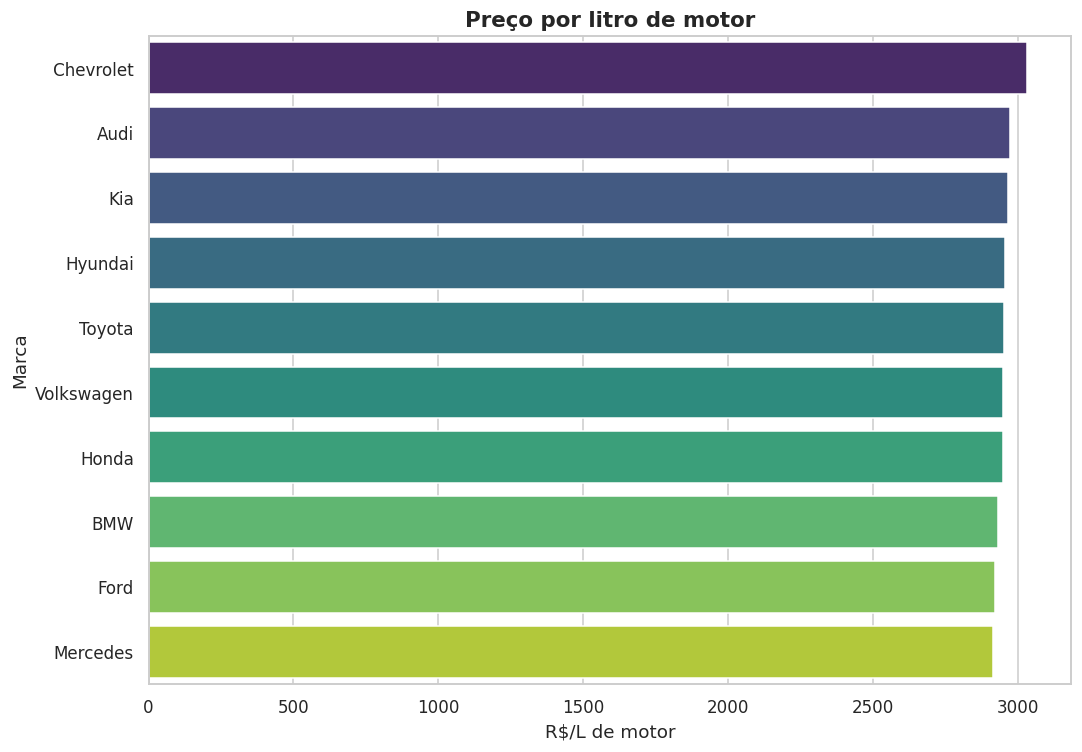

In [ ]:
df2["preco_por_litro"] = (
    df2["price"] / df2["engine_size"]
)

ranking = (
    df2.groupby("brand")["preco_por_litro"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    x=ranking.values,
    y=ranking.index,
    palette=PALETTE,
    ax=ax
)

ax.set_title("Preço por litro de motor")
ax.set_xlabel("R$/L de motor")
ax.set_ylabel("Marca")

plt.tight_layout()
plt.show()

# 5. Combustível dos carros mais caros (quartis)

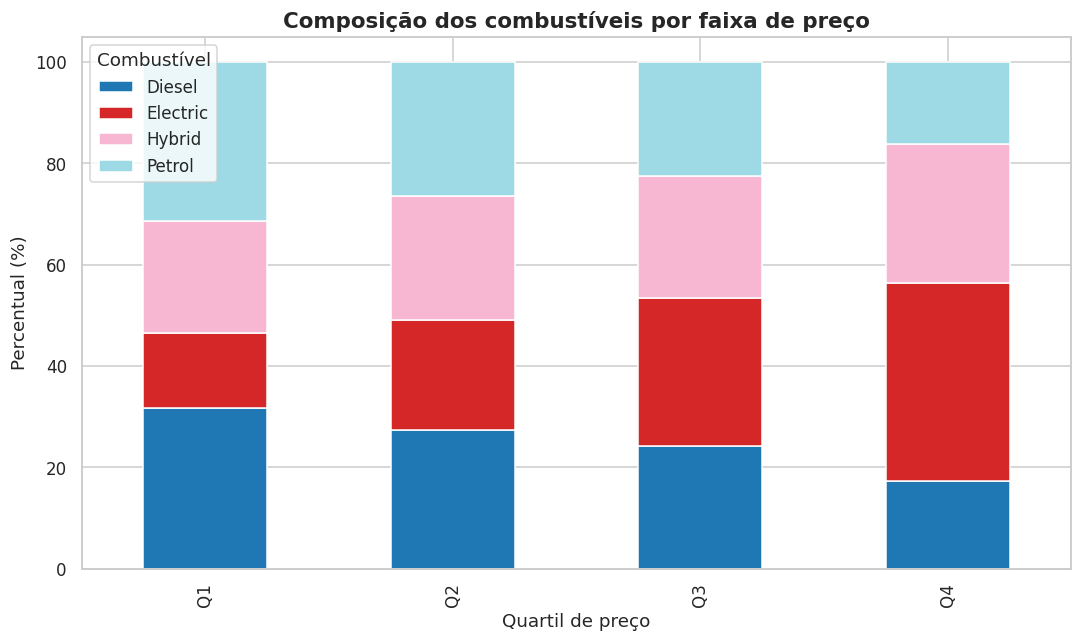

In [ ]:
df2["faixa_preco"] = pd.qcut(
    df2["price"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

comp = pd.crosstab(
    df2["faixa_preco"],
    df2["fuel_type"],
    normalize="index"
) * 100

comp.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)

plt.title("Composição dos combustíveis por faixa de preço")
plt.xlabel("Quartil de preço")
plt.ylabel("Percentual (%)")
plt.legend(title="Combustível")
plt.tight_layout()
plt.show()

# 7. Qual combustível envelhece melhor?

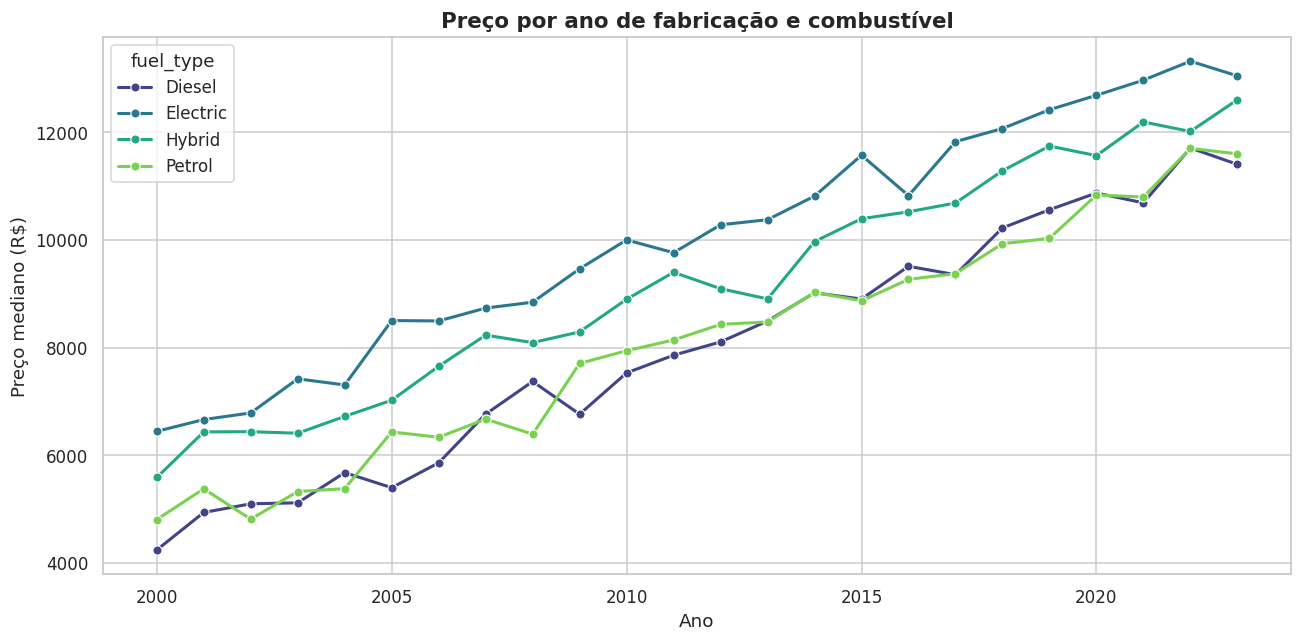

In [ ]:
evolucao = (
    df2.groupby(["year", "fuel_type"])["price"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=evolucao,
    x="year",
    y="price",
    hue="fuel_type",
    marker="o",
    linewidth=2,
    palette=PALETTE,
    ax=ax
)

ax.set_title("Preço por ano de fabricação e combustível")
ax.set_xlabel("Ano")
ax.set_ylabel("Preço mediano (R$)")

plt.tight_layout()
plt.show()

# 8. Ranking das marcas mais valorizadas

/tmp/ipykernel_2468/3200545924.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


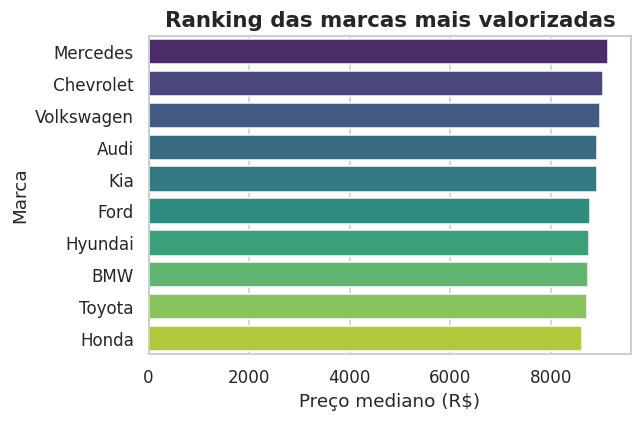

In [ ]:
top = (
    df2.groupby("brand")["price"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    x=top.values,
    y=top.index,
    palette=PALETTE,
    ax=ax
)

ax.set_title("Ranking das marcas mais valorizadas")
ax.set_xlabel("Preço mediano (R$)")
ax.set_ylabel("Marca")

plt.tight_layout()
plt.show()